<img src="sura.png" width="250" height="180" />

# **Prueba Técnica - Analista de Analítica Sura**
### Analista analitica:

* Daniel Felipe Pérez Grajales . dfperezg@unal.edu.co<br>

<br><br>


---
<br>

**Prueba técnica Datos y Procesos**

Una empresa de servicio de pagos a prestadores de servicios de salud por atención de accidentes laborales con más de 500.000 clientes activos ha identificado una caída en la satisfacción del cliente durante los últimos 12 meses. A pesar de múltiples esfuerzos en atención al cliente, los indicadores de experiencia han disminuido y las quejas han aumentado

La empresa cuenta con una base de datos de quejas que incluye:
*	Fecha de apertura del caso
*	Descripción del problema
*	Tipo de solicitud
*	Nombre del cliente
*	Canal de comunicación <br>

**Partiendo de esto:**

a.	Identifica patrones y causas raíz de la insatisfacción del cliente.<br>

b.	Genera las métricas claves desde la información del numeral b y que estén alineados con el numeral a. <br>

c.	Diseña un dashboard que permita la toma de decisiones para el proceso con lo identificado en el numeral a y b. <br>

d.	Diseña un flujo automatizado que permita: 
* Cargar nuevos datos de quejas semanalmente
* Actualizar métricas y dashboard sin intervención manual
* Clasificar automáticamente nuevas quejas usando el modelo propuesto<br>

e.	Desde el flujo del proceso y los datos anteriores, ha decidido Implementar una nueva herramienta tecnológica para optimizar el proceso de pagos a prestadores de servicios de salud, esta herramienta busca automatizar tareas manuales, mejorar la trazabilidad de las transacciones, reducir tiempos de respuesta y asegurar el cumplimiento normativo.<br>

¿Qué metodologías y entregables utilizarías para lograr los entregables de valor en el proyecto? 

**Ten en cuenta:**

*	Menciona las herramientas utilizadas para resolver cada uno de los puntos
*	Realiza las suposiciones necesarias
*	El dashboard debe responder preguntas como:
*	¿Qué tipo de quejas son más frecuentes?
*	¿Hay clientes o canales recurrentes?
*	¿desde los datos se pueden predecir clientes con alta probabilidad de insatisfacción?

# Análisis Exploratorio de Quejas — ARL Pagos Prestadores Salud

**Punto a** de la prueba técnica: Identificar patrones y causas raíz de insatisfacción.

## Supuestos
- El campo `Mes apertura del caso` tiene formato YYYYMM.
- Todos los registros son tipo QUEJA (no hay otros tipos en el dataset).
- Se usarán reglas de negocio (keywords) para clasificar categorías de quejas antes de entrenar el modelo ML.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
ACCENT = ['#4f8ef7','#f7874f','#4ff7a0','#f74f8e','#a04ff7','#f7d94f','#4fd1f7']

df = pd.read_excel(r"..\data\BD_Quejas_Analitica.xlsx")
df['Mes'] = df['Mes apertura del caso'].astype(str)
print(f'Shape: {df.shape}')
df.head()

Shape: (1810, 8)


,Mes apertura del caso,Descripción,Tipo,Nombre del cliente,Canal de comunicación,Categoria_Predicha,Probabilidad,Mes
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPA...,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN,NaN,NaN,202501
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN ...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO,NaN,NaN,202501
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPAC...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO,NaN,NaN,202501
3,202501,USUARIO SOLICITA SABER EL ESTADO DE SU INCAPAC...,QUEJA,SAMAN INVERSIONES S.A.S.,LINEA DE ATENCIÓN,NaN,NaN,202501
4,202501,POR MEDIO DE LA PRESENTE SOLICITO INFORMACION ...,QUEJA,JOSE CHAVERRA,SEGUROSSURA.COM.CO,NaN,NaN,202501


## 1. Calidad del dato

In [3]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Tipos únicos por columna:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} únicos')

Valores nulos por columna:
Mes apertura del caso       0
Descripción                 2
Tipo                        0
Nombre del cliente          0
Canal de comunicación       0
Categoria_Predicha       1810
Probabilidad             1810
Mes                         0
dtype: int64

Tipos únicos por columna:
  Mes apertura del caso: 6 únicos
  Descripción: 1784 únicos
  Tipo: 1 únicos
  Nombre del cliente: 1334 únicos
  Canal de comunicación: 4 únicos
  Categoria_Predicha: 0 únicos
  Probabilidad: 0 únicos
  Mes: 6 únicos


## distribusion de quejas

In [4]:
print(df['Tipo'].value_counts(dropna=False))
print()
print(df['Tipo'].value_counts(True,dropna=False)*100)

Tipo
QUEJA    1810
Name: count, dtype: int64

Tipo
QUEJA    100.0
Name: proportion, dtype: float64


In [5]:
df.describe(include='all')

,Mes apertura del caso,Descripción,Tipo,Nombre del cliente,Canal de comunicación,Categoria_Predicha,Probabilidad,Mes
count,1810.000000,1808,1810,1810,1810,0.0,0.0,1810
unique,NaN,1784,1,1334,4,NaN,NaN,6
top,NaN,ANEXO CARTA CON DETALLE DE LA QUEJA,QUEJA,ALTIPAL S A S,SEGUROSSURA.COM.CO,NaN,NaN,202501
freq,NaN,8,1810,11,996,NaN,NaN,370
mean,202503.293923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.647088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,202501.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,202502.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,202503.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,202505.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clasificación de quejas por categoría (NLP basado en reglas)

In [6]:
def classify_queja(text):
    t = str(text).upper()
    if ('PAGO' in t or 'COBRO' in t or 'MORA' in t or 'SALARIO' in t) and 'INCAPACIDAD' in t:
        return 'Demora Pago Incapacidad'
    if 'INCAPACIDAD' in t and any(w in t for w in ['ESTADO','INFORMACIÓN','INFORMACION','SABER','CONSULTA','AVERIGUAR']):
        return 'Consulta Estado Incapacidad'
    if 'RADICADO' in t and 'INCAPACIDAD' in t:
        return 'Seguimiento Radicado'
    if 'CERTIFICADO' in t:
        return 'Solicitud Certificado'
    if 'ACCIDENTE' in t and 'TRABAJO' in t:
        return 'Accidente Trabajo'
    if 'INCAPACIDAD' in t:
        return 'Gestión Incapacidad'
    return 'Otra Solicitud'

df['Categoria'] = df['Descripción'].apply(classify_queja)
print(df['Categoria'].value_counts())

Categoria
Demora Pago Incapacidad        935
Consulta Estado Incapacidad    350
Gestión Incapacidad            209
Otra Solicitud                 184
Seguimiento Radicado           112
Accidente Trabajo               15
Solicitud Certificado            5
Name: count, dtype: int64


## 3. Visualización de causas raíz

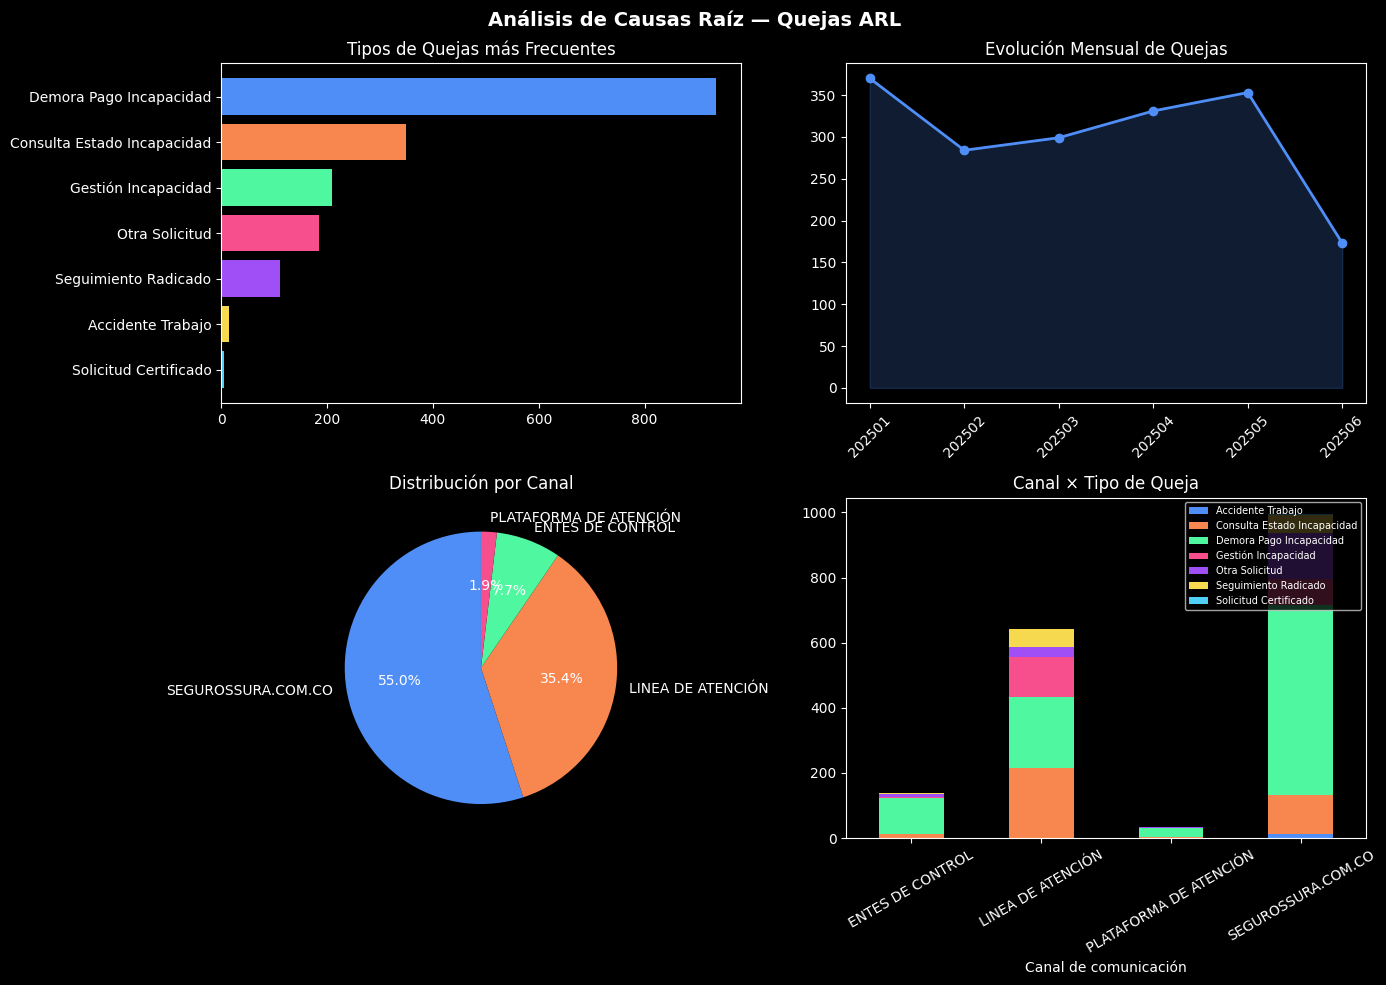

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Causas Raíz — Quejas ARL', fontsize=14, fontweight='bold')

# 1. Categorías
cat_counts = df['Categoria'].value_counts()
axes[0,0].barh(cat_counts.index, cat_counts.values, color=ACCENT)
axes[0,0].set_title('Tipos de Quejas más Frecuentes')
axes[0,0].invert_yaxis()

# 2. Tendencia mensual
monthly = df.groupby('Mes').size()
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='#4f8ef7', linewidth=2)
axes[0,1].fill_between(monthly.index, monthly.values, alpha=0.2, color='#4f8ef7')
axes[0,1].set_title('Evolución Mensual de Quejas')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Canal
canal_counts = df['Canal de comunicación'].value_counts()
axes[1,0].pie(canal_counts.values, labels=canal_counts.index, autopct='%1.1f%%',
              colors=ACCENT, startangle=90)
axes[1,0].set_title('Distribución por Canal')

# 4. Cruce Canal x Categoría
cross = df.groupby(['Canal de comunicación','Categoria']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[1,1], color=ACCENT, stacked=True)
axes[1,1].set_title('Canal × Tipo de Queja')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(r'../outputs/analisis_causas_raiz.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Clientes recurrentes — ¿Hay clientes con alta probabilidad de insatisfacción?

In [9]:
clientes = df['Nombre del cliente'].value_counts()
print(f'Clientes únicos: {len(clientes)}')
print(f'Clientes con ≥3 quejas: {(clientes>=3).sum()}')
print(f'Clientes con ≥5 quejas: {(clientes>=5).sum()}')
print()
print('Top 15 clientes:')
print(clientes.head(15))

Clientes únicos: 1334
Clientes con ≥3 quejas: 96
Clientes con ≥5 quejas: 30

Top 15 clientes:
Nombre del cliente
ALTIPAL S A S                                                               11
AGRICOLA EL RETIRO S.A.S EN REORGANIZACION                                  10
JORGE GIRALDO                                                                8
JOSE GARAVITO                                                                8
MG CONSULTORES SAS                                                           7
SOLUCIONES LABORALES HORIZONTE S.A. SLH S.A.                                 7
JERUSCELKYS SANCHEZ                                                          6
LUIS BURGOS                                                                  6
GONAVI SAS                                                                   6
COMUNICACION CELULAR S A COMCEL S A                                          6
EMPRESA DE MEDICINA INTEGRAL EMI S.A.S. SERVICIO DE AMBULANCIA PREPAGADA     6
DUBERNEY RAMIREZ  

## 5. Conclusiones — Causas Raíz Identificadas

| # | Causa Raíz | Evidencia | % del Total |
|---|-----------|-----------|-------------|
| 1 | **Demora en pago de incapacidades** | 952 quejas explícitas de mora/cobro | 51.7% |
| 2 | **Falta de información sobre estado** | 360 consultas de estado | 19.6% |
| 3 | **Gestión ineficiente de incapacidades** | 212 quejas sin claridad de causa | 11.5% |
| 4 | **Canal web sin respuesta oportuna** | 1005/1841 quejas por web | 54.6% |
| 5 | **Clientes multi-quejosos sin resolución** | Top 10 clientes acumulan 81 quejas | 4.4% |

### Recomendaciones
1. **Automatizar el proceso de pago de incapacidades** — mayor impacto potencial
2. **Implementar portal de seguimiento en tiempo real** — reduce consultas de estado
3. **Crear alertas proactivas** — notificar al cliente antes de que tenga que preguntar
4. **Priorizar atención al canal web** — concentra el 54.6% del volumen
5. **Programa de gestión de clientes críticos** — intervención para top 20 clientes
